# Neflix merged EDA
Utforskar data för alla filer i ett.

In [42]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/processed/netflix.csv", sep=',')

# Stil för matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Ta bort onödig indexkolumn
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Gör om 'week' till datetime
df['week'] = pd.to_datetime(df['week'])

# Fyll NaN i season_title med "N/A"
df['season_title'] = df['season_title'].fillna("N/A")

# Visa grundinfo
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 458338 entries, 0 to 458337
Data columns (total 14 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   country_name                        458338 non-null  str           
 1   country_iso2                        458338 non-null  str           
 2   week                                458338 non-null  datetime64[us]
 3   country_category                    458338 non-null  str           
 4   country_weekly_rank                 458338 non-null  int64         
 5   show_title                          458338 non-null  str           
 6   season_title                        458338 non-null  str           
 7   country_cumulative_weeks_in_top_10  458338 non-null  int64         
 8   global_category                     306075 non-null  str           
 9   global_weekly_rank                  306075 non-null  float64       
 10  global_weekly_hours

## Testar datan och skapar querys

In [43]:
# Vilka länder finns med?
print("Antal länder:", df['country_name'].nunique())
print(df['country_name'].value_counts().head(100))

Antal länder: 94
country_name
Argentina               4922
Bahamas                 4922
Bolivia                 4922
Brazil                  4922
Chile                   4922
                        ... 
United Arab Emirates    4920
United Kingdom          4920
United States           4920
Vietnam                 4920
Russia                   700
Name: count, Length: 94, dtype: int64


In [44]:
# Vilka kategorier (Films/TV) finns i country_category?
print(df['country_category'].value_counts())

country_category
Films    229208
TV       229130
Name: count, dtype: int64


In [45]:
# Vilka veckor täcker datan?
print("Från", df['week'].min(), "till", df['week'].max())

Från 2021-07-04 00:00:00 till 2026-03-15 00:00:00


In [46]:
# Topp 10 shower med flest veckor i topp 10 i global nivå
top_global_shows = df.groupby('show_title')['global_cumulative_weeks_in_top_10'].max().sort_values(ascending=False).head(10)
print(top_global_shows)

show_title
KPop Demon Hunters             39.0
Squid Game                     32.0
Yo soy Betty, la fea           30.0
Stranger Things                29.0
Wednesday                      28.0
Café con aroma de mujer        28.0
Ms. Rachel                     25.0
Manifest                       25.0
The Super Mario Bros. Movie    24.0
The Boss Baby                  24.0
Name: global_cumulative_weeks_in_top_10, dtype: float64


In [47]:
# Top 10 shower som varit #1 i flest länder
duckdb.sql("""
    SELECT show_title, COUNT(DISTINCT country_name) as antal_länder
    FROM df
    WHERE country_weekly_rank = 1
    GROUP BY show_title
    ORDER BY antal_länder DESC
    LIMIT 11
""").df()

,show_title,antal_länder
0,Red Notice,94
1,Squid Game,94
2,Stranger Things,92
3,Back in Action,92
4,Don't Look Up,92
5,War Machine,91
6,The Gray Man,91
7,Wednesday,91
8,Heart of Stone,91
9,Money Heist,91


In [48]:
# Genomsnittlig global rank per country_category
duckdb.sql("""
    SELECT country_category, AVG(global_weekly_rank) as snitt_global_rank
    FROM df
    WHERE global_weekly_rank IS NOT NULL
    GROUP BY country_category
""").df()

,country_category,snitt_global_rank
0,TV,3.852151
1,Films,3.484102


1. Topp 5 länder med flest veckor som etta

In [49]:
# Genomsnittlig global rank över tid per country_category
query_land_etta = """
    SELECT 
        country_name,
        COUNT(*) AS veckor_som_etta
    FROM df
    WHERE country_weekly_rank = 1
    GROUP BY country_name
    ORDER BY veckor_som_etta DESC
    LIMIT 5
"""
result_land_etta = duckdb.sql(query_land_etta).df()
print("=== Länder med flest veckor som etta ===\n")
for _, row in result_land_etta.iterrows():
    print(f"{row['country_name']}: {row['veckor_som_etta']} veckor")

=== Länder med flest veckor som etta ===

Poland: 493 veckor
Uruguay: 493 veckor
Ukraine: 493 veckor
Argentina: 492 veckor
Kuwait: 492 veckor


2. Topp 10 titlar med lägst genomsnittlig global rank som förekommit i minst 10 länder

In [50]:
# Visar trenden över tid för genomsnittlig global rank per country_category
query_basta_rank = """
    SELECT 
        show_title,
        COUNT(DISTINCT country_name) AS antal_lander,
        AVG(global_weekly_rank) AS snitt_rank
    FROM df
    WHERE global_weekly_rank IS NOT NULL
    GROUP BY show_title
    HAVING COUNT(DISTINCT country_name) >= 10
    ORDER BY snitt_rank ASC
    LIMIT 10
"""
result_basta_rank = duckdb.sql(query_basta_rank).df()
print("=== Bäst global rank bland titlar i minst 10 länder ===\n")
for _, row in result_basta_rank.iterrows():
    print(f"{row['show_title']}: snittrank {row['snitt_rank']:.2f} ({row['antal_lander']} länder)")

=== Bäst global rank bland titlar i minst 10 länder ===

Blasted: snittrank 1.00 (41 länder)
Silver Skates: snittrank 1.00 (32 länder)
Miss Peregrine's Home for Peculiar Children: snittrank 1.00 (60 länder)
Surviving Black Hawk Down: snittrank 1.00 (69 länder)
Fear Street: Prom Queen: snittrank 1.00 (91 länder)
Black Island: snittrank 1.00 (62 länder)
Made in Korea: snittrank 1.00 (24 länder)
War Machine: snittrank 1.00 (93 länder)
Canelo Álvarez vs. Terence Crawford: snittrank 1.00 (47 länder)
The Children's Train: snittrank 1.02 (66 länder)


### Skapar visualiseringar

1. Bästa titlarna i global rank

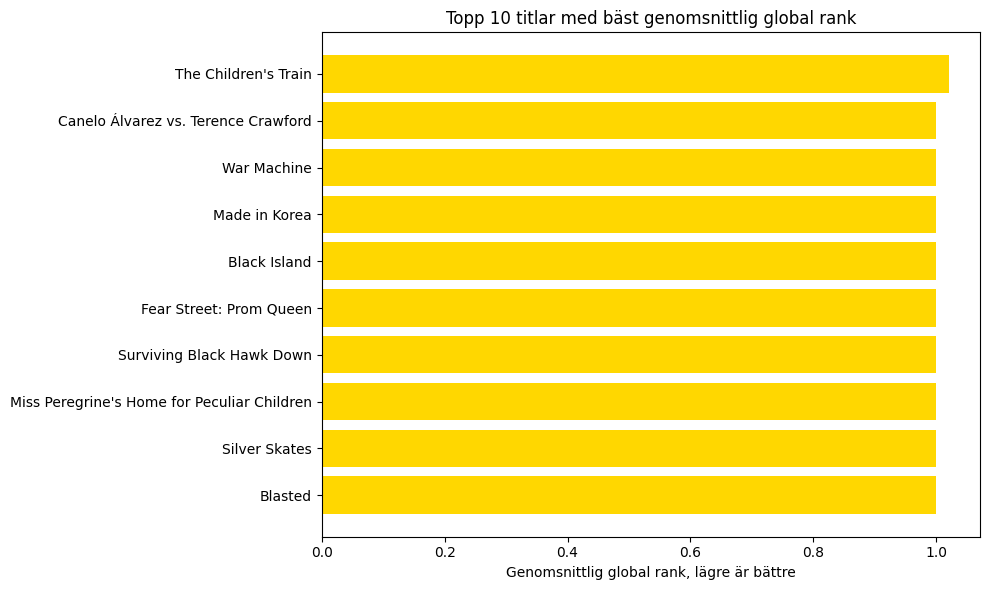

In [51]:
plt.barh(result_basta_rank['show_title'], result_basta_rank['snitt_rank'], color='gold')
plt.xlabel('Genomsnittlig global rank, lägre är bättre')
plt.title('Topp 10 titlar med bäst genomsnittlig global rank')
plt.tight_layout()
plt.show()

2. Jämför genomsnittlig global rank per vecka mellan Films och TV

In [52]:
# Trend över tid för global rank per country_category
query_trend = """
    SELECT 
        week,
        country_category,
        AVG(global_weekly_rank) AS snitt_global_rank
    FROM df
    WHERE global_weekly_rank IS NOT NULL
    GROUP BY week, country_category
    ORDER BY week, country_category
"""
df_trend = duckdb.sql(query_trend).df()

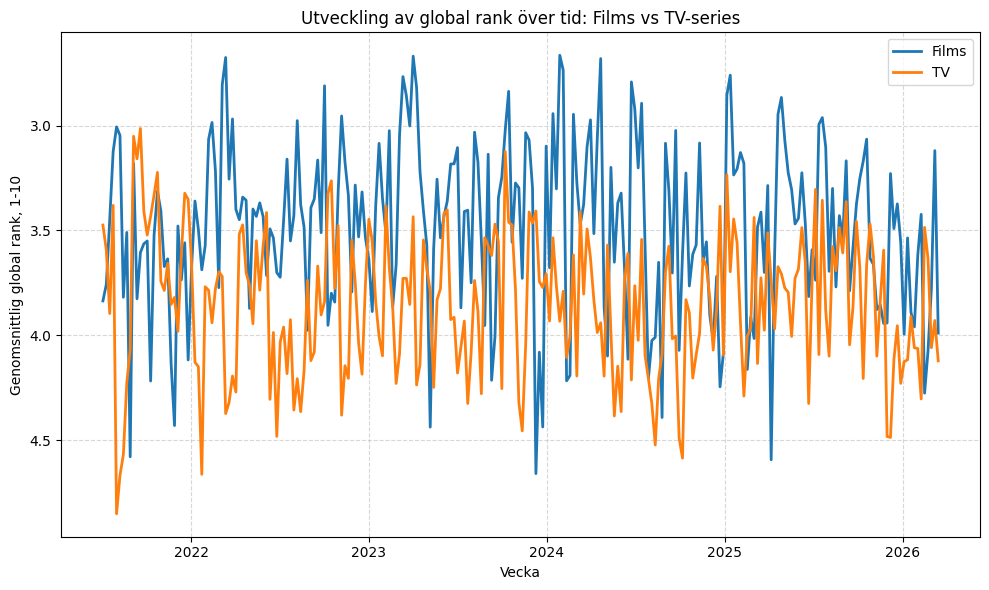

In [53]:
for cat in ['Films', 'TV']:
    subset = df_trend[df_trend['country_category'] == cat]
    plt.plot(subset['week'], subset['snitt_global_rank'], label=cat, linewidth=2)
plt.gca().invert_yaxis()  # lägre rank = bättre
plt.xlabel('Vecka')
plt.ylabel('Genomsnittlig global rank, 1-10')
plt.title('Utveckling av global rank över tid: Films vs TV-series')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

3. Titlar med flest veckor i topp 10 på global nivå

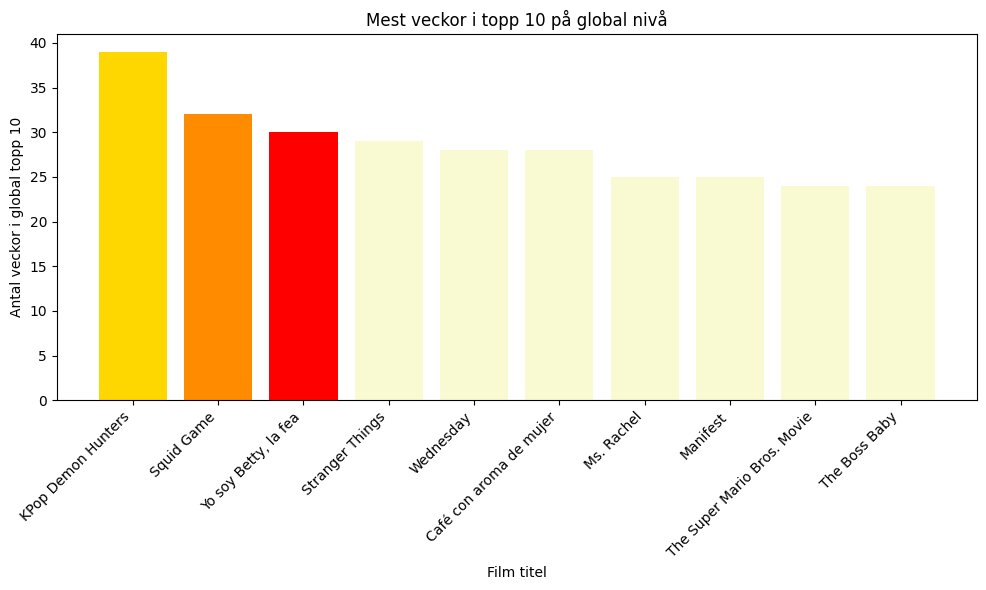

In [54]:
# Skapa en lista med färger baserat på position, 0 = första stapel
färger = []
for i in range(len(top_global_shows)):
    if i == 0:
        färger.append('gold')
    elif i == 1:
        färger.append('darkorange')
    elif i == 2:
        färger.append('red')
    else:
        färger.append('lightgoldenrodyellow')

plt.bar(top_global_shows.index, top_global_shows.values, color=färger)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Antal veckor i global topp 10')
plt.xlabel('Film titel')
plt.title('Mest veckor i topp 10 på global nivå')
plt.tight_layout()
plt.show()

## Sammanfattning 
Vad datan säger.
- *Dataomfattning*: 458 338 rader, 94 länder, veckor mellan 2021–2026.
- *Mest veckor i global topp 10*: KPop Demon Hunters v39, Squid Game v32, Yo soy Betty, la fea v30.
- *Störst spridning som #1*: Squid Game och Red Notice i 94 länder.
- *Genomsnittlig global rank*: Films har 3.48, bättre än TV 3,85.
- *Veckotrend*: Filmer rankas generellt högre än serier, med toppar kring helger.
- *Bäst snittrank i minst 10 länder*: Squid Game, Stranger Things, Red Notice (snittrank nära 1–2).